In [33]:
library(ape)
library(ggtree)
library(ggplot2)
library(patchwork)
library(treeio)
library(phytools)
# set input and output paths

indir <- "../../results/mrbayes/full_run"
outdir <- file.path(indir, "tree_plots")
if (!dir.exists(outdir)) dir.create(outdir, recursive = TRUE, showWarnings = FALSE)

# color tips by biological lineage / comparison group
lineage_df <- data.frame(
    label = c("Bg", "Ee", "Bb", "Pk", "Ip"),
    lineage = c(
        "South American electric fishes",
        "South American electric fishes",
        "African weakly electric fishes",
        "African weakly electric fishes",
        "Ictaluridae outgroup"
    )
)

lineage_palette <- c(
    "South American electric fishes" = "#1b9e77",
    "African weakly electric fishes" = "#d95f02",
    "Ictaluridae outgroup" = "#7570b3"
)

lineage_shapes <- c(
    "South American electric fishes" = 21,
    "African weakly electric fishes" = 22,
    "Ictaluridae outgroup" = 24
)

In [34]:
## function to plot the tree with colored tips and optional node labels, and save as PDF and PNG
plot_mrbayes_tree <- function(tree, outfile_prefix, plot_title, show_node_labels = TRUE) {

    p <- ggtree(tree, layout = "rectangular", size = 0.9) %<+% lineage_df +
        geom_tippoint( aes(color = lineage, shape = lineage), size = 3, fill = "white", stroke = 1.1 ) +
        geom_tiplab( aes(color = lineage), size = 4, fontface = "bold", offset = 0.01, show.legend = FALSE ) +
        scale_color_manual(values = lineage_palette, name = "Lineage / group") +
        scale_shape_manual(values = lineage_shapes, name = "Lineage / group") +
        ggtitle(plot_title) +
        theme_tree2() +
        theme( plot.title = element_text(hjust = 0.5, face = "bold", size = 14), legend.position = "right", legend.title = element_text(face = "bold") )

    if (show_node_labels) {
        p <- p +
            geom_label2( aes(subset = !isTip & !is.na(label) & label != "", label = label), hjust = -0.15, vjust = -0.35, size = 3, label.size = 0.2, fill = "white", color = "gray25" )
        }

    pdf_file <- paste0(outfile_prefix, ".pdf")
    png_file <- paste0(outfile_prefix, ".png")

    ggsave(pdf_file, plot = p, width = 8, height = 5)
    ggsave(png_file, plot = p, width = 8, height = 5, dpi = 300)

    cat("")
    return(p)
}

#
plot_cophylo_colored <- function(outfile, type = c("pdf", "png")) {
    type <- match.arg(type)

    if (type == "pdf") {
        pdf(outfile, width = 13, height = 8)
    } else {
        png(outfile, width = 3900, height = 2400, res = 300)
    }

    par(mar = c(2, 2, 6, 10), xpd = NA)
    plot(co, fsize = 1.1, ftype = "i", link.type = "curved", link.lwd = 3, link.col = link_cols, pts = TRUE, pch = 21, mar = c(2, 2, 6, 10))
    mtext("IQ-TREE NT tree vs MrBayes consensus tree", side = 3, line = 3, cex = 1.4, font = 2)
    dev.off()
}

MrBayes treedata object:
'treedata' S4 object that stored information
of
	'../../results/mrbayes/full_run/full_run_mrbayes.nex.con.tre'.

...@ phylo:

Phylogenetic tree with 5 tips and 3 internal nodes.

Tip labels:
  Bg, Ip, Pk, Ee, Bb

Unrooted; includes branch length(s).

with the following features available:
  'length_0.95HPD', 'length_mean', 'length_median', 'prob', 'prob_range',
'prob_stddev', 'prob_percent', 'prob+-sd'.

# The associated data tibble abstraction: 8 × 11
# The 'node', 'label' and 'isTip' are from the phylo tree.
   node label isTip length_0.95HPD length_mean  length_median prob  prob_range
  <int> <chr> <lgl> <list>         <chr>        <chr>         <chr> <list>    
1     1 Bg    TRUE  <dbl [2]>      0.0872382579 0.08722181    1     <dbl [2]> 
2     2 Ip    TRUE  <dbl [2]>      0.18454798   0.1845247     1     <dbl [2]> 
3     3 Pk    TRUE  <dbl [2]>      0.0271165878 0.02714285    1     <dbl [2]> 
4     4 Ee    TRUE  <dbl [2]>      0.0727682914 0.07279651    1 

Unrooted tree:

Phylogenetic tree with 5 tips and 3 internal nodes.

Tip labels:
  Bg, Ip, Pk, Ee, Bb

Unrooted; includes branch length(s).


Warning message in geom_label2(aes(subset = !isTip & !is.na(label) & label != "", :
“Ignoring unknown parameters: `label.size`”


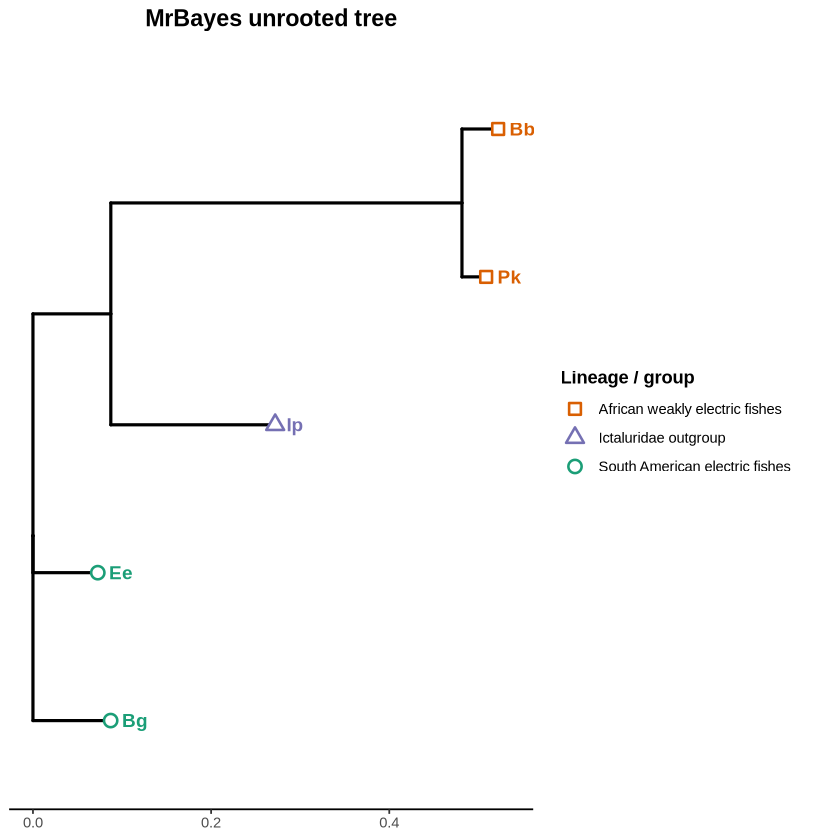

In [35]:
# read the tree and plot the unrooted tree

mb_td <- read.mrbayes(file.path(indir, "full_run_mrbayes.nex.con.tre"))

cat("MrBayes treedata object:\n")
print(mb_td)

mb_tree <- as.phylo(mb_td)

cat("Unrooted tree:\n")
print(mb_tree)

# treeio keeps MrBayes posterior probabilities as annotations, but ape/phylo does not
# always store them as node.label. The regular tree plot focuses on topology and lineages.
plot_mrbayes_tree(mb_tree, file.path(outdir, "mrbayes_unrooted"), "MrBayes unrooted tree" )

Rooted tree:

Phylogenetic tree with 5 tips and 4 internal nodes.

Tip labels:
  Bg, Ip, Pk, Ee, Bb

Rooted; includes branch length(s).


Warning message in geom_label2(aes(subset = !isTip & !is.na(label) & label != "", :
“Ignoring unknown parameters: `label.size`”


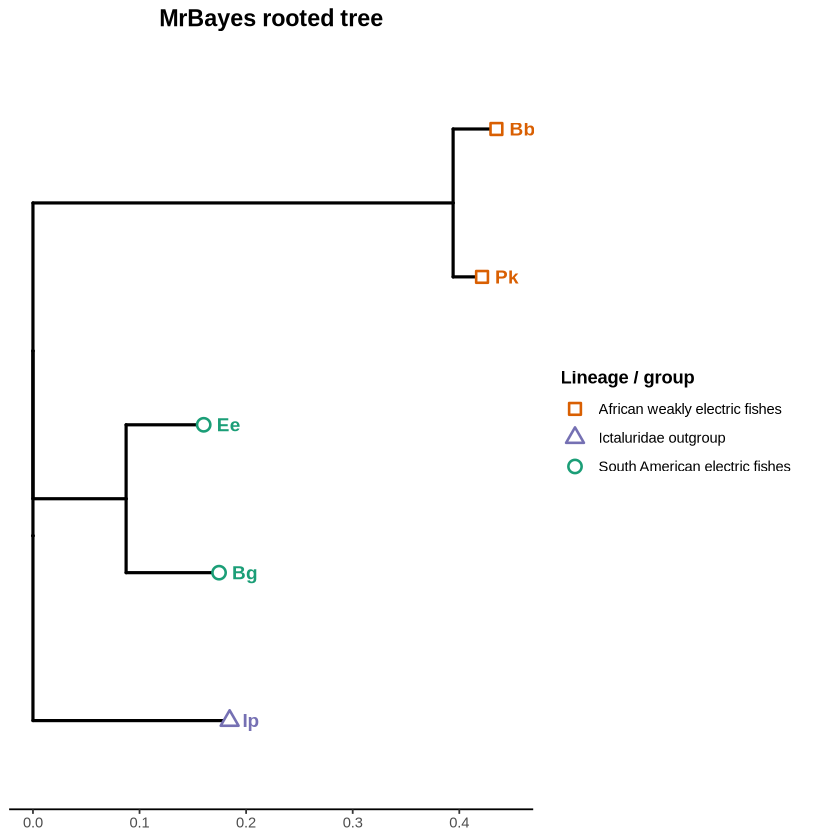

In [36]:
# root the tree using outgroup and plot

mb_rooted <- root(mb_tree, outgroup = "Ip", resolve.root = TRUE)
mb_rooted <- ladderize(mb_rooted)

cat("Rooted tree:\n")
print(mb_rooted)

plot_mrbayes_tree(mb_rooted, file.path(outdir, "mrbayes_rooted"), "MrBayes rooted tree" )

=> Comparing iq_rooted with mb_rooted_compare.
Both trees have the same number of tips: 5.
Both trees have the same tip labels.
Both trees have the same number of nodes: 3.
Both trees are unrooted.
Both trees are not ultrametric.
3 splits in common.

Robinson-Foulds distance: 0 Rotating nodes to optimize matching...
Done.


agg_record_472280615 
                   2

agg_record_472280615 
                   2

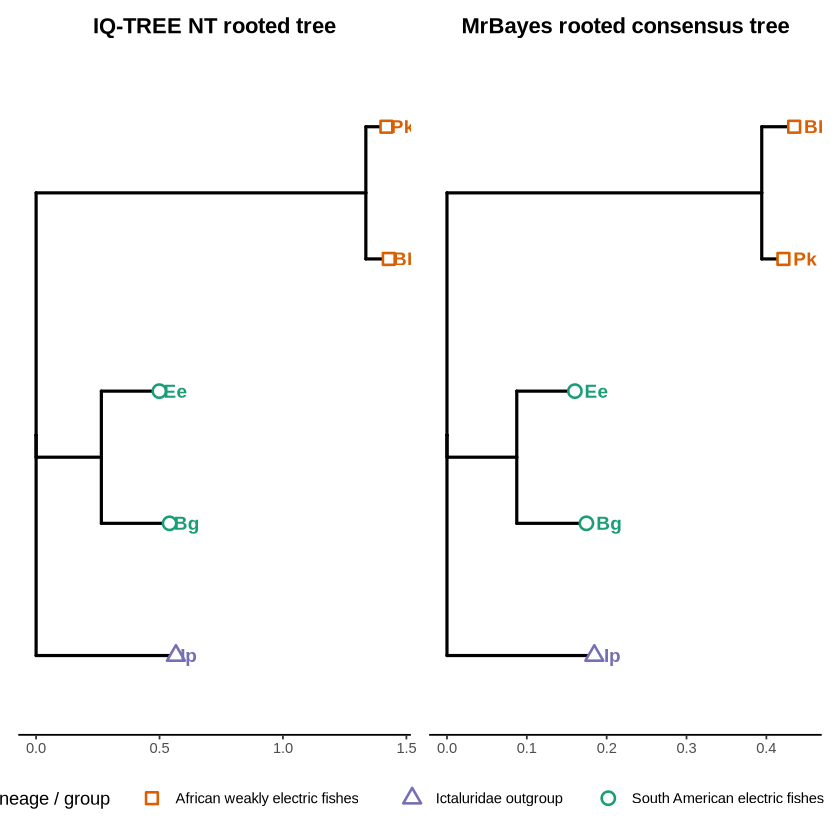

In [37]:
## compare NT IQ-TREE and MrBayes trees

iq_file <- "../../results/ml_iqtree/nt_partitioned/nt_partitioned.treefile"
mb_file <- file.path(indir, "full_run_mrbayes.nex.con.tre")

compare_outdir <- file.path(outdir, "comparison_iqtree_mrbayes")
dir.create(compare_outdir, recursive = TRUE, showWarnings = FALSE)

iq_tree <- read.tree(iq_file)
mb_tree_compare <- read.nexus(mb_file)

if (inherits(mb_tree_compare, "multiPhylo")) {
    mb_tree_compare <- mb_tree_compare[[1]]
}

if (!setequal(iq_tree$tip.label, mb_tree_compare$tip.label)) {
    stop("Tip labels do not match between IQ-TREE and MrBayes trees.")
}

outgroup <- "Ip"

iq_rooted <- root(iq_tree, outgroup = outgroup, resolve.root = FALSE)
mb_rooted_compare <- root(mb_tree_compare, outgroup = outgroup, resolve.root = FALSE)

iq_rooted <- ladderize(iq_rooted)
mb_rooted_compare <- ladderize(mb_rooted_compare)

# Remove support annotations before topology comparison.
# IQ-TREE node labels are support values, while MrBayes posterior probabilities
# are stored as extended annotations in the .con.tre file.
iq_rooted$node.label <- NULL
mb_rooted_compare$node.label <- NULL

compare_result <- capture.output(comparePhylo(iq_rooted, mb_rooted_compare))
writeLines(compare_result)
writeLines(compare_result, file.path(compare_outdir, "comparePhylo_iqtree_nt_vs_mrbayes.txt"))

rf <- dist.topo(iq_rooted, mb_rooted_compare)
cat("Robinson-Foulds distance:", rf, "")
writeLines( paste("Robinson-Foulds distance:", rf), file.path(compare_outdir, "rf_distance_iqtree_nt_vs_mrbayes.txt"))

assoc <- cbind(iq_rooted$tip.label, iq_rooted$tip.label)
link_cols <- lineage_palette[lineage_df$lineage[match(assoc[, 1], lineage_df$label)]]

co <- cophylo( iq_rooted, mb_rooted_compare, assoc = assoc, rotate = TRUE)

plot_cophylo_colored(file.path(compare_outdir, "cophylo_iqtree_nt_vs_mrbayes.pdf"), type = "pdf")
plot_cophylo_colored(file.path(compare_outdir, "cophylo_iqtree_nt_vs_mrbayes.png"), type = "png")

# Also save cleaner side-by-side ggtree plots.
p_iq <- ggtree(iq_rooted, size = 0.9) %<+% lineage_df +
    geom_tippoint(aes(color = lineage, shape = lineage), size = 3, fill = "white", stroke = 1.1) +
    geom_tiplab(aes(color = lineage), size = 4, fontface = "bold", offset = 0.01, show.legend = FALSE) +
    scale_color_manual(values = lineage_palette, name = "Lineage / group") +
    scale_shape_manual(values = lineage_shapes, name = "Lineage / group") +
    ggtitle("IQ-TREE NT rooted tree") +
    theme_tree2() +
    theme(plot.title = element_text(hjust = 0.5, face = "bold"))

p_mb <- ggtree(mb_rooted_compare, size = 0.9) %<+% lineage_df +
    geom_tippoint(aes(color = lineage, shape = lineage), size = 3, fill = "white", stroke = 1.1) +
    geom_tiplab(aes(color = lineage), size = 4, fontface = "bold", offset = 0.01, show.legend = FALSE) +
    scale_color_manual(values = lineage_palette, name = "Lineage / group") +
    scale_shape_manual(values = lineage_shapes, name = "Lineage / group") +
    ggtitle("MrBayes rooted consensus tree") +
    theme_tree2() +
    theme(plot.title = element_text(hjust = 0.5, face = "bold"))

side_by_side <- p_iq + p_mb + plot_layout(ncol = 2, guides = "collect") &
    theme(legend.position = "bottom")

ggsave( filename = file.path(compare_outdir, "iqtree_nt_mrbayes_side_by_side.pdf"), plot = side_by_side, width = 14, height = 6 )

ggsave( filename = file.path(compare_outdir, "iqtree_nt_mrbayes_side_by_side.png"), plot = side_by_side, width = 14, height = 6, dpi = 300)

side_by_side
